# DSBDA Practicals

In [41]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import nltk
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.naive_bayes import GaussianNB
from sklearn.feature_extraction.text import TfidfVectorizer


## Data Wrangling, I
Perform the following operations using Python on dataset (e.g., `employee.csv`)
1. Import all the required Python Libraries, and load the dataset into pandas DataFrame.
2. Data preprocessing: find the missing values in the data column-wise and display statistical information.
3. Provide variable descriptions, types of variables etc. Check the dimensions of the DataFrame.
4. Data formatting: summarize the types of variables by checking the data types (character, numeric, integer, factor, logical). If variables are not in the correct data type, apply proper type conversions.
5. Data normalization: perform Z-score transformation and plot box plot for any column.
6. Turn categorical variables into quantitative variables in Python.

Missing values:
 Name          0
Age           1
Salary        1
Gender        0
Department    0
dtype: int64

Describe :
              Age        Salary
count   4.000000      4.000000
mean   29.500000  65000.000000
std     4.203173  12909.944487
min    25.000000  50000.000000
25%    27.250000  57500.000000
50%    29.000000  65000.000000
75%    31.250000  72500.000000
max    35.000000  80000.000000

Info:
<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Name        5 non-null      str    
 1   Age         4 non-null      float64
 2   Salary      4 non-null      float64
 3   Gender      5 non-null      str    
 4   Department  5 non-null      str    
dtypes: float64(2), str(3)
memory usage: 332.0 bytes
None
Shape: (5, 5)


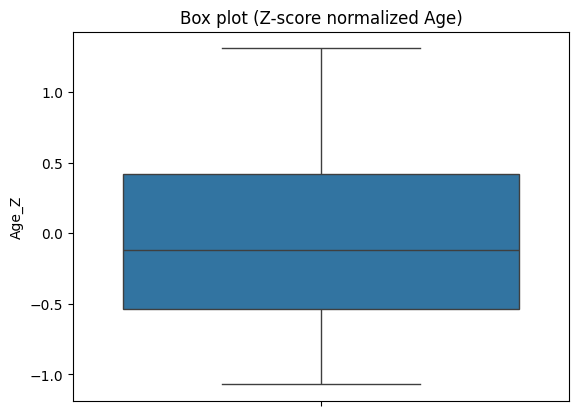

/tmp/ipykernel_57402/1229299093.py:19: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns


,Age,Salary,Age_Z,Name_Alice,Name_Bob,Name_Charlie,Name_David,Name_Eve,Gender_Female,Gender_Male,Department_HR,Department_IT,Department_Sales
0,25.0,50000.0,-1.070620,True,False,False,False,False,True,False,True,False,False
1,30.0,60000.0,0.118958,False,True,False,False,False,False,True,False,True,False
2,NaN,70000.0,NaN,False,False,True,False,False,False,True,False,True,False
3,35.0,80000.0,1.308535,False,False,False,True,False,False,True,False,False,True
4,28.0,NaN,-0.356873,False,False,False,False,True,True,False,True,False,False


In [46]:
df = pd.read_csv('employee.csv')
print('Missing values:\n', df.isnull().sum())
print('\nDescribe :\n', df.describe())
print('\nInfo:')
print(df.info())
print('Shape:', df.shape)

# Ensure numeric types where needed
if 'Salary' in df.columns:
    df['Salary'] = pd.to_numeric(df['Salary'], errors='coerce')

# Z-score normalization (example: Age) + box plot
df['Age_Z'] = (df['Age'] - df['Age'].mean()) / df['Age'].std()
sns.boxplot(y=df['Age_Z'])
plt.title('Box plot (Z-score normalized Age)')
plt.show()

# Turn categorical variables into quantitative variables (one-hot encoding)
cat_cols = df.select_dtypes(include=['object']).columns
df_enc = pd.get_dummies(df, columns=cat_cols, drop_first=False)
df_enc.head()

## Data Wrangling, I
Perform the following operations using Python on dataset (e.g., `student.csv`)
1. Import all the required Python Libraries, and load the dataset into pandas DataFrame.
2. Data preprocessing: find the missing values in the data and display statistical information.
3. Provide variable descriptions, types of variables etc. Check the dimensions of the DataFrame.
4. Data normalization: perform min-max normalization and plot box plot for any column.
5. Turn categorical variables for `PG` column into quantitative variables in Python.

Name      0
Gender    0
PG        0
Marks     1
Age       0
dtype: int64
       Marks        Age
count    3.0   4.000000
mean    50.0  21.500000
std     10.0   1.290994
min     40.0  20.000000
25%     45.0  20.750000
50%     50.0  21.500000
75%     55.0  22.250000
max     60.0  23.000000
<class 'pandas.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Name    4 non-null      str    
 1   Gender  4 non-null      str    
 2   PG      4 non-null      str    
 3   Marks   3 non-null      float64
 4   Age     4 non-null      int64  
dtypes: float64(1), int64(1), str(3)
memory usage: 292.0 bytes
None
Shape: (4, 5)


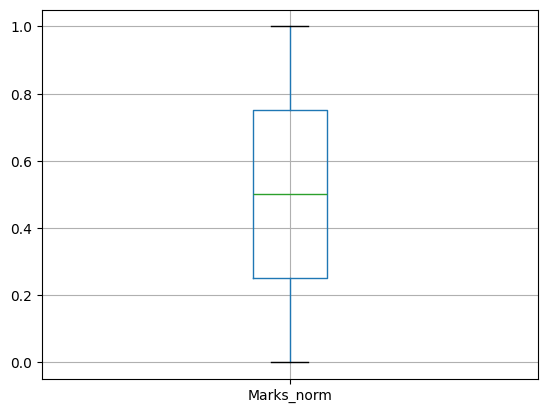

,Name,Gender,PG,Marks,Age,Marks_norm
0,A,M,1,50.0,20,0.5
1,B,F,0,60.0,21,1.0
2,C,M,1,40.0,22,0.0
3,D,F,0,NaN,23,NaN


In [47]:
df_stu = pd.read_csv('student.csv')
print(df_stu.isnull().sum())
print(df_stu.describe())
print(df_stu.info())
print('Shape:', df_stu.shape)
df_stu['Marks_norm'] = (df_stu['Marks'] - df_stu['Marks'].min()) / (df_stu['Marks'].max() - df_stu['Marks'].min())
df_stu.boxplot(column=['Marks_norm'])
plt.show()
df_stu['PG'] = df_stu['PG'].map({'Yes': 1, 'No': 0})
df_stu.head()

## Data Wrangling II (Missing values: mean/mode, Outliers: z-score, Binning)
Perform the following operations using Python (e.g., `Academic_Performance.csv`)
1. Scan all variables for missing values and inconsistencies. If there are missing values and/or inconsistencies, use suitable techniques to deal with them (using mean and mode). Apply for single column and whole dataset.
2. Scan all numeric variables for outliers. If there are outliers, use suitable techniques to deal with them (using z-score).
3. Display and remove the outliers.
4. Apply data transformations on at least one variable: create bins and labels.
5. Draw box plot.

Outliers rows: 0


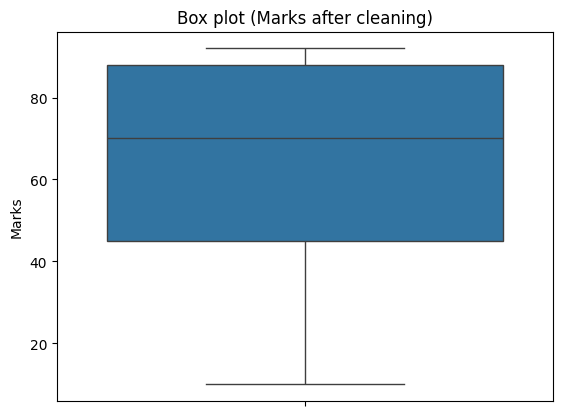

,RollNo,Name,Score,Age,Marks,Grade
0,1,Sita,85.0,20,88,High
1,2,Gita,90.0,21,92,High
2,3,Ram,100.0,20,45,Avg
3,4,Sham,150.0,22,70,Avg
4,5,Tina,75.0,19,10,Low


In [48]:
df_ap = pd.read_csv('Academic_Performance.csv')

# Missing values: apply mean for a single column, mode for whole dataset
df_ap['Score'] = df_ap['Score'].fillna(df_ap['Score'].mean())
df_ap = df_ap.fillna(df_ap.mode().iloc[0])

# Outliers: scan numeric variables using z-score and remove rows with any |z|>=3
numeric_cols = df_ap.select_dtypes(include=[np.number]).columns
z_scores = ((df_ap[numeric_cols] - df_ap[numeric_cols].mean()) / df_ap[numeric_cols].std()).abs()
outlier_mask = (z_scores >= 3).any(axis=1)
outliers = df_ap[outlier_mask]
print('Outliers rows:', outliers.shape[0])

df_ap_clean = df_ap[~outlier_mask].copy()

# Binning (example: Marks)
df_ap_clean['Grade'] = pd.cut(df_ap_clean['Marks'], bins=[0, 40, 70, 100], labels=['Low', 'Avg', 'High'])

# Box plot (example: Marks)
sns.boxplot(y=df_ap_clean['Marks'])
plt.title('Box plot (Marks after cleaning)')
plt.show()

df_ap_clean.head()

## Data Wrangling II (Missing values: median/0, Outliers: IQR, Aggregation + Transform)
Perform the following operations using Python (e.g., `Academic_Performance.csv`)
1. Scan all variables for missing values and inconsistencies. If there are missing values and/or inconsistencies, use suitable techniques to deal with them (using median and 0). Apply for single column and whole dataset.
2. Scan all numeric variables for outliers. If there are outliers, use suitable techniques to deal with them (using IQR).
3. Display and remove the outliers; show Q1 and Q3.
4. Apply aggregation function (max, avg). Apply a transformation for one of the following: change scale, convert non-linear relation to linear, or reduce skewness/normalize distribution. Document the approach.
5. Draw scatter plot.

Q1: 45.0 Q3: 88.0 IQR: 43.0
Rows before: 5 after IQR filter: 5
Aggregation (Marks):
 max     92.0
mean    61.0
Name: Marks, dtype: float64


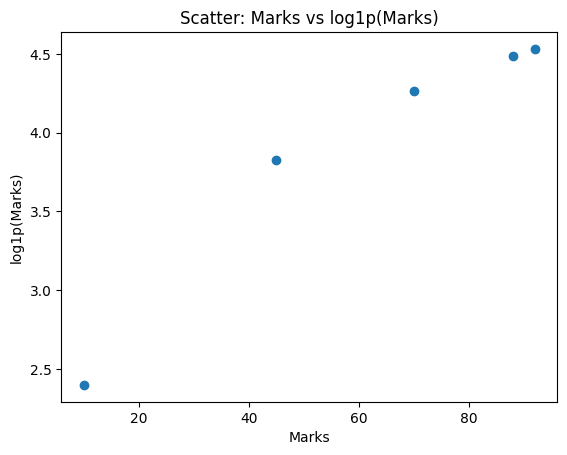

In [49]:
df_ap2 = pd.read_csv('Academic_Performance.csv')

# Missing values: median for one column, 0 for whole dataset
df_ap2['Score'] = df_ap2['Score'].fillna(df_ap2['Score'].median())
df_ap2 = df_ap2.fillna(0)

# Outliers using IQR (example: Marks)
q1 = df_ap2['Marks'].quantile(0.25)
q3 = df_ap2['Marks'].quantile(0.75)
iqr = q3 - q1
print('Q1:', q1, 'Q3:', q3, 'IQR:', iqr)

filtered = df_ap2[(df_ap2['Marks'] >= q1 - 1.5 * iqr) & (df_ap2['Marks'] <= q3 + 1.5 * iqr)].copy()
print('Rows before:', df_ap2.shape[0], 'after IQR filter:', filtered.shape[0])

# Aggregation
agg = filtered['Marks'].agg(['max', 'mean'])
print('Aggregation (Marks):\n', agg)

# Transformation: log1p to reduce skewness / change scale
filtered['Marks_log'] = np.log1p(filtered['Marks'])

# Scatter plot
plt.scatter(filtered['Marks'], filtered['Marks_log'])
plt.xlabel('Marks')
plt.ylabel('log1p(Marks)')
plt.title('Scatter: Marks vs log1p(Marks)')
plt.show()

## Descriptive Statistics (Mean, Median, Minimum)
Measures of Central Tendency and variability. Perform the following operations on any open source dataset (e.g., `data.csv`)
1. Provide summary statistics (mean, median, minimum) for numeric variables (age, salary etc.).
2. Group by one qualitative (categorical) variable and provide summary statistics of a numeric variable (e.g., income grouped by age groups).
3. Perform grouping on and display `JOB_ID` and its count.
4. Show data visualization for any column.

         income
mean    48000.0
median  50000.0
min     30000.0
          count     mean          std      min      25%      50%      75%  \
AgeGroup                                                                    
Adult       2.0  62500.0  3535.533906  60000.0  61250.0  62500.0  63750.0   
Senior      1.0  50000.0          NaN  50000.0  50000.0  50000.0  50000.0   
Youth       2.0  32500.0  3535.533906  30000.0  31250.0  32500.0  33750.0   

              max  
AgeGroup           
Adult     65000.0  
Senior    50000.0  
Youth     35000.0  
JOB_ID
101    2
102    2
103    1
Name: count, dtype: int64


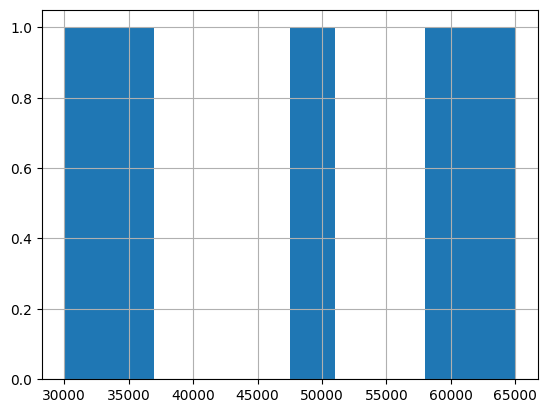

In [50]:
df_desc = pd.read_csv('data.csv')
print(df_desc[['income']].agg(['mean', 'median', 'min']))
print(df_desc.groupby('AgeGroup')['income'].describe())
print(df_desc['JOB_ID'].value_counts())
df_desc['income'].hist()
plt.show()

## Descriptive Statistics (Maximum, Std Dev, Covariance)
Measures of Central Tendency and variability. Perform the following operations on any open source dataset (e.g., `data.csv`)
1. Provide summary statistics (maximum, standard deviation, covariance) for numeric variables (age, salary etc.).
2. Group by one qualitative (categorical) variable and provide summary statistics of a numeric variable (e.g., income grouped by age groups).
3. Perform grouping on and display `JOB_ID` and its count.
4. Show data visualization for any column.

           income        ID
max  65000.000000  5.000000
std  15247.950682  1.581139
             income       ID
income  232500000.0  15000.0
ID          15000.0      2.5
          count     mean          std      min      25%      50%      75%  \
AgeGroup                                                                    
Adult       2.0  62500.0  3535.533906  60000.0  61250.0  62500.0  63750.0   
Senior      1.0  50000.0          NaN  50000.0  50000.0  50000.0  50000.0   
Youth       2.0  32500.0  3535.533906  30000.0  31250.0  32500.0  33750.0   

              max  
AgeGroup           
Adult     65000.0  
Senior    50000.0  
Youth     35000.0  
JOB_ID
101    2
102    2
103    1
Name: count, dtype: int64


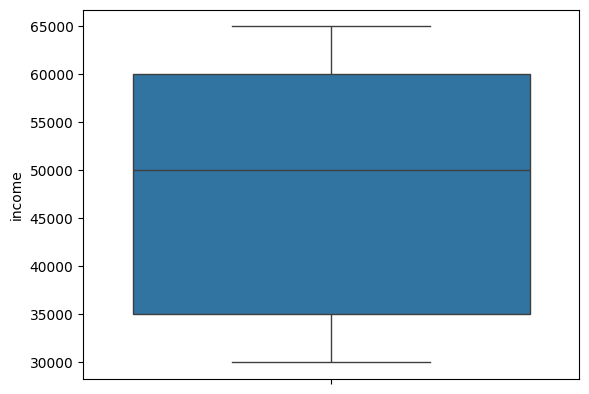

In [51]:
print(df_desc[['income', 'ID']].agg(['max', 'std']))
print(df_desc[['income', 'ID']].cov())
print(df_desc.groupby('AgeGroup')['income'].describe())
print(df_desc['JOB_ID'].value_counts())
sns.boxplot(y=df_desc['income'])
plt.show()

## Data Analytics I (Linear Regression - Boston Housing)
Reference: https://www.youtube.com/watch?v=QcPycBZomac
Create a Linear Regression Model using Python/R to predict home prices using Boston Housing Dataset.
The Boston Housing dataset contains information about various houses in Boston through different parameters. There are 506 samples and 14 feature variables in this dataset. The objective is to predict house prices using the given features.

In [52]:
from sklearn.datasets import fetch_openml

try:
    boston = fetch_openml(name='boston', version=1, as_frame=True)
    X_b = boston.data
    y_b = boston.target
    X_train, X_test, y_train, y_test = train_test_split(X_b, y_b, test_size=0.2, random_state=42)
    model_b = LinearRegression().fit(X_train, y_train)
    sample = X_b.iloc[0:1]
    print('Predicted price for sample:', model_b.predict(sample))
except Exception as e:
    print('Boston dataset download failed:', e)
    print('Ensure internet access or provide a local boston.csv if required.')

Boston dataset download failed: can't multiply sequence by non-int of type 'float'
Ensure internet access or provide a local boston.csv if required.


## Data Analytics I (Linear Regression - Salary)
Reference: https://www.youtube.com/watch?v=QcPycBZomac
Create a Linear Regression Model using Python/R to predict salary of 15 years of experience using `salary.csv` file.
Sample data:
- Experience Salary
- 5 20000
- 7 25000
- 9 40000
- 12 60000
- 18 80000
- 20 110000

In [53]:
df_sal = pd.read_csv('salary.csv')
X = df_sal[['Experience']]
y = df_sal['Salary']
model = LinearRegression().fit(X, y)

pred_15 = model.predict(pd.DataFrame({'Experience': [15]}))[0]
print('Prediction for 15 years:', pred_15)

Prediction for 15 years: 73687.32907930721


## Data Analytics II (Logistic Regression - Social Network Ads)
1. Implement logistic regression using Python/R to perform classification on `Social_Network_Ads.csv` dataset.
2. Compute confusion matrix to find TP, FP, TN, FN, Accuracy, Error rate, Precision, Recall on the given dataset.

In [54]:
from sklearn.metrics import confusion_matrix

df_ads = pd.read_csv('Social_Network_Ads.csv')
X = df_ads[['Age', 'EstimatedSalary']]
y = df_ads['Purchased']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_lr = LogisticRegression(max_iter=1000)
model_lr.fit(X_train, y_train)
y_pred = model_lr.predict(X_test)

cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()

accuracy = (tp + tn) / (tp + tn + fp + fn)
error_rate = 1 - accuracy
precision = tp / (tp + fp) if (tp + fp) else 0.0
recall = tp / (tp + fn) if (tp + fn) else 0.0

print('Confusion Matrix:\n', cm)
print('TP, FP, TN, FN:', tp, fp, tn, fn)
print('Accuracy:', accuracy)
print('Error rate:', error_rate)
print('Precision:', precision)
print('Recall:', recall)

Confusion Matrix:
 [[2 0]
 [0 0]]
TP, FP, TN, FN: 0 0 2 0
Accuracy: 1.0
Error rate: 0.0
Precision: 0.0
Recall: 0.0


## Data Analytics II (Logistic Regression - Study Hours)
Reference: https://www.youtube.com/watch?v=UCOm-LFKX9E
1. Implement logistic regression using Python/R to perform classification on study hours dataset.
Sample data:
- STUDY HOURS PASS/FAIL
- 29 0
- 15 0
- 33 1
- 48 1
- 39 1
2. Find the logistic regression prediction for student if they study 25 and 42 hours.
3. Compute confusion matrix to find TP, FP, TN, FN, Accuracy, Error rate, Precision, Recall on the given dataset.

In [55]:
df_hours = pd.read_csv('student_hours.csv')
X = df_hours[['Hours']]
y = df_hours['Pass']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_h = LogisticRegression(max_iter=1000)
model_h.fit(X_train, y_train)

print('Pred 25 hours:', model_h.predict(pd.DataFrame({'Hours': [25]}))[0])
print('Pred 42 hours:', model_h.predict(pd.DataFrame({'Hours': [42]}))[0])

y_pred = model_h.predict(X_test)
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()

accuracy = (tp + tn) / (tp + tn + fp + fn)
error_rate = 1 - accuracy
precision = tp / (tp + fp) if (tp + fp) else 0.0
recall = tp / (tp + fn) if (tp + fn) else 0.0

print('Confusion Matrix:\n', cm)
print('TP, FP, TN, FN:', tp, fp, tn, fn)
print('Accuracy:', accuracy)
print('Error rate:', error_rate)
print('Precision:', precision)
print('Recall:', recall)

Pred 25 hours: 0
Pred 42 hours: 1
Confusion Matrix:
 [[1 0]
 [0 0]]
TP, FP, TN, FN: 0 0 1 0
Accuracy: 1.0
Error rate: 0.0
Precision: 0.0
Recall: 0.0


## Data Analytics III (Naive Bayes - Iris)
For Naive Bayes: https://www.youtube.com/watch?v=XzSlEA4ck2I
For confusion matrix: https://www.youtube.com/watch?v=_CGTbkHwUHQ
1. Implement Simple Naive Bayes classification algorithm using Python/R on `iris.csv` dataset.
2. Compute confusion matrix to find TP, FP, TN, FN, Accuracy, Error rate, Precision, Recall on the given dataset.

In [56]:
from sklearn.metrics import confusion_matrix

df_iris = pd.read_csv('iris.csv')
X = df_iris.drop(columns=['target'])
y = df_iris['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred = nb.predict(X_test)

labels = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)
print('Confusion Matrix (rows=true, cols=pred):\n', cm)

accuracy = cm.trace() / cm.sum()
error_rate = 1 - accuracy
print('Accuracy:', accuracy)
print('Error rate:', error_rate)

# For multi-class: compute TP/FP/TN/FN + precision/recall per class (one-vs-rest)
total = cm.sum()
for i, label in enumerate(labels):
    tp = cm[i, i]
    fn = cm[i, :].sum() - tp
    fp = cm[:, i].sum() - tp
    tn = total - (tp + fp + fn)
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    print(f"\nClass {label}: TP={tp}, FP={fp}, TN={tn}, FN={fn}")
    print(f"Precision={precision:.4f}, Recall={recall:.4f}")

Confusion Matrix (rows=true, cols=pred):
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
Accuracy: 1.0
Error rate: 0.0

Class 0: TP=10, FP=0, TN=20, FN=0
Precision=1.0000, Recall=1.0000

Class 1: TP=9, FP=0, TN=21, FN=0
Precision=1.0000, Recall=1.0000

Class 2: TP=11, FP=0, TN=19, FN=0
Precision=1.0000, Recall=1.0000


## Text Analytics
Reference: https://www.youtube.com/watch?v=8F_ERPqN0T0
1. Extract sample document and apply document preprocessing: Tokenization, POS tagging, stop words removal, stemming and lemmatization.
2. Create representation of document by calculating Term Frequency (TF) and Inverse Document Frequency (IDF).

In [57]:
from collections import Counter
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer

doc = 'Data science uses statistics and machine learning for insights.'

try:
    nltk.download('punkt', quiet=True)
    nltk.download('averaged_perceptron_tagger', quiet=True)
    nltk.download('stopwords', quiet=True)
    nltk.download('wordnet', quiet=True)

    tokens = word_tokenize(doc.lower())
    pos_tags = nltk.pos_tag(tokens)
    stops = set(stopwords.words('english'))
    filtered = [t for t in tokens if t.isalpha() and t not in stops]
    stemmer = PorterStemmer()
    lemmatizer = WordNetLemmatizer()
    stemmed = [stemmer.stem(t) for t in filtered]
    lemmatized = [lemmatizer.lemmatize(t) for t in filtered]
except Exception as e:
    print('NLTK data download failed, using simple fallback:', e)
    tokens = [t.strip('.,').lower() for t in doc.split()]
    pos_tags = []
    filtered = [t for t in tokens if t.isalpha()]
    stemmed = filtered
    lemmatized = filtered

print('Tokens:', tokens)
print('POS:', pos_tags)
print('Filtered:', filtered)
print('Stemmed:', stemmed)
print('Lemmatized:', lemmatized)

# Term Frequency (TF)
tf = Counter(filtered)
print('\nTF:', dict(tf))

# TF-IDF (for a single document this is still computable)
tfidf = TfidfVectorizer()
tfidf_matrix = tfidf.fit_transform([doc])
terms = tfidf.get_feature_names_out()
scores = tfidf_matrix.toarray().ravel()
print('\nTF-IDF:', dict(zip(terms, scores)))

Tokens: ['data', 'science', 'uses', 'statistics', 'and', 'machine', 'learning', 'for', 'insights', '.']
POS: [('data', 'NNS'), ('science', 'NN'), ('uses', 'VBZ'), ('statistics', 'NNS'), ('and', 'CC'), ('machine', 'NN'), ('learning', 'NN'), ('for', 'IN'), ('insights', 'NNS'), ('.', '.')]
Filtered: ['data', 'science', 'uses', 'statistics', 'machine', 'learning', 'insights']
Stemmed: ['data', 'scienc', 'use', 'statist', 'machin', 'learn', 'insight']
Lemmatized: ['data', 'science', 'us', 'statistic', 'machine', 'learning', 'insight']

TF: {'data': 1, 'science': 1, 'uses': 1, 'statistics': 1, 'machine': 1, 'learning': 1, 'insights': 1}

TF-IDF: {'and': np.float64(0.3333333333333333), 'data': np.float64(0.3333333333333333), 'for': np.float64(0.3333333333333333), 'insights': np.float64(0.3333333333333333), 'learning': np.float64(0.3333333333333333), 'machine': np.float64(0.3333333333333333), 'science': np.float64(0.3333333333333333), 'statistics': np.float64(0.3333333333333333), 'uses': np.fl

## Data Visualization I
1. Use the inbuilt dataset `titanic`. The dataset contains 891 rows and contains information about the passengers who boarded the unfortunate Titanic ship. Use the Seaborn library to see if we can find any patterns in the data.
2. Write code to check how the price of the ticket (column name: `fare`) for each passenger is distributed by plotting a histogram.

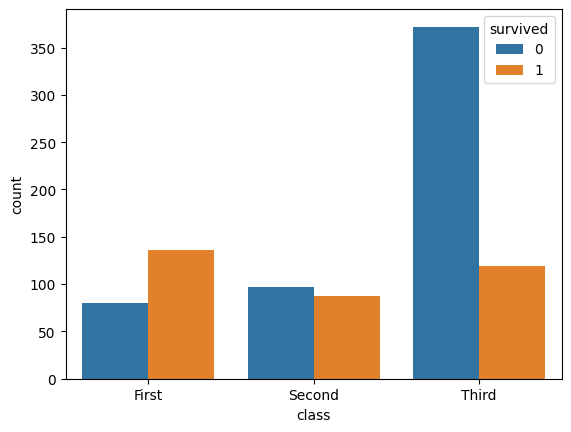

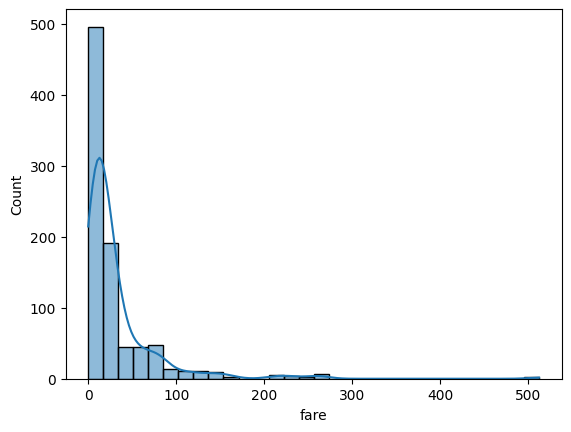

In [58]:

titanic = sns.load_dataset('titanic')

sns.countplot(x='class', hue='survived', data=titanic)
plt.show()
sns.histplot(titanic['fare'], bins=30, kde=True)
plt.show()

## Data Visualization II
1. Use the inbuilt dataset `titanic`. Plot a box plot for distribution of age with respect to each gender along with the information about whether they survived or not (column names: `sex`, `age`, `survived`).
2. Write observations on the inference from the above statistics.

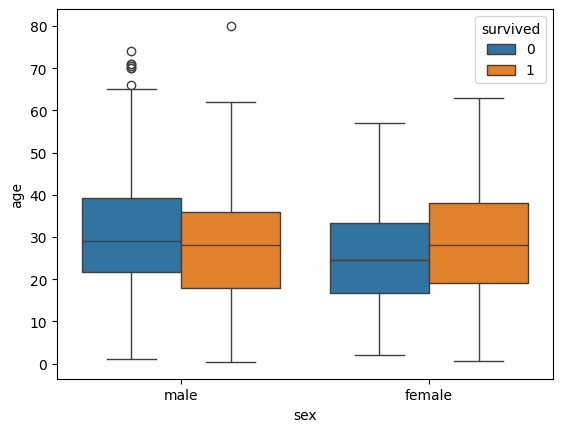

In [59]:
titanic = sns.load_dataset('titanic')
sns.boxplot(x='sex', y='age', hue='survived', data=titanic)
plt.show()

Observations:
- Add your inference here based on the box plot (e.g., median age differences by sex, effect of survival, presence of outliers).

## Data Visualization III
Use the Iris flower dataset or any other dataset into a DataFrame. Scan the dataset and give the inference as:
1. List down the features and their types (e.g., numeric, nominal) available in the dataset.
2. Create a histogram for each feature in the dataset to illustrate the feature distributions.
3. Create a box plot for each feature in the dataset.
4. Compare distributions and identify outliers.

Feature types:
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species             str
dtype: object


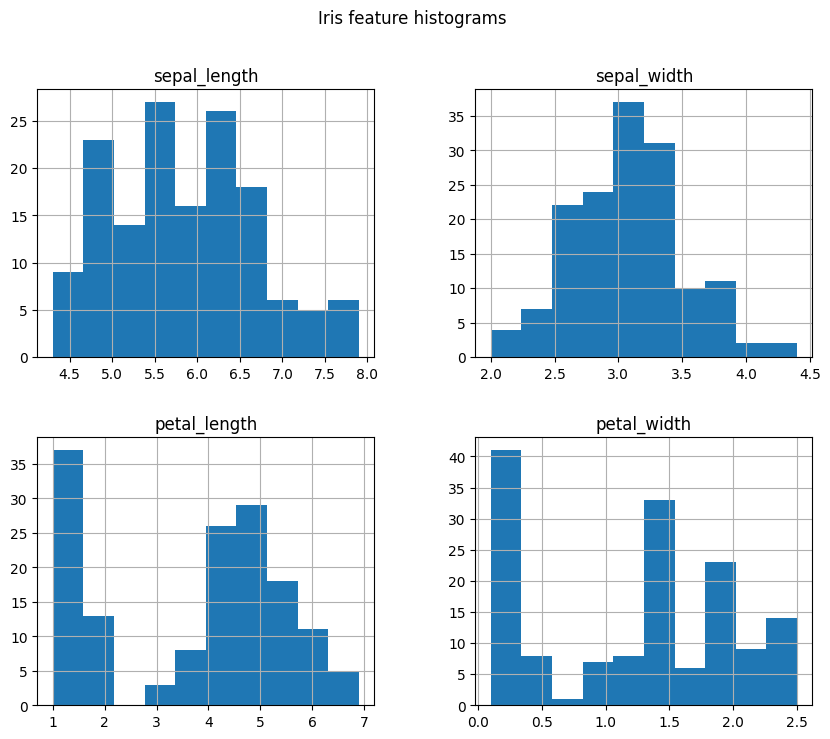

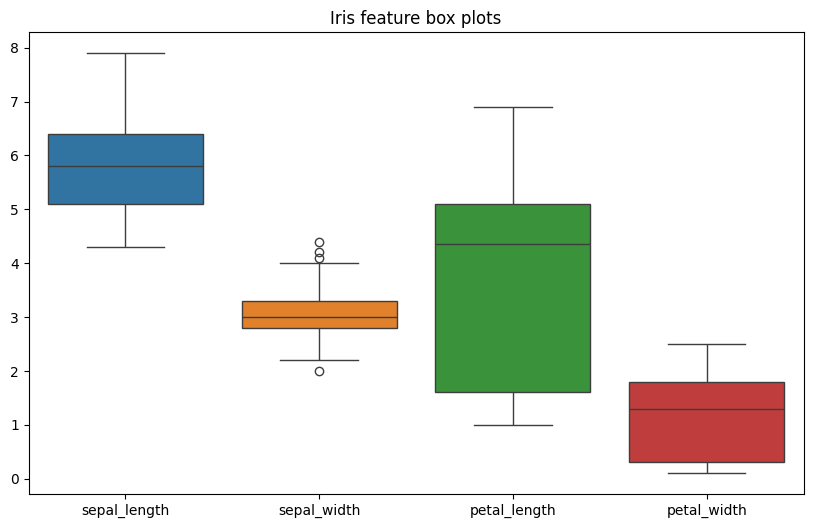

In [60]:
df = sns.load_dataset('iris')

print('Feature types:')
print(df.dtypes)

# Histograms for each numeric feature
df.hist(figsize=(10, 8))
plt.suptitle('Iris feature histograms')
plt.show()

# Box plots for each numeric feature
plt.figure(figsize=(10, 6))
sns.boxplot(data=df.select_dtypes(include=[np.number]))
plt.title('Iris feature box plots')
plt.show()


Estimate conditional probabilities of each attributes {color, legs, height, smelly} for the species classes: {M, H} using the data given in the table.

Using these probabilities estimate the probability values for the new instance – 
(Color=Green, legs=2, Height=Tall, and Smelly=No).

| No | Color | Legs | Height | Smelly | Species |
| :--- | :--- | :--- | :--- | :--- | :--- |
| 1 | White | 3 | Short | Yes | M |
| 2 | Green | 2 | Tall | No | M |
| 3 | Green | 3 | Short | Yes | M |
| 4 | White | 3 | Short | Yes | M |
| 5 | Green | 2 | Short | No | H |
| 6 | White | 2 | Tall | No | H |
| 7 | White | 2 | Tall | No | H |
| 8 | White | 2 | Short | Yes | H |

In [61]:
table = pd.DataFrame({
    'Color': ['White', 'Green', 'Green', 'White', 'Green', 'White', 'White', 'White'],
    'Legs': [3, 2, 3, 3, 2, 2, 2, 2],
    'Height': ['Short', 'Tall', 'Short', 'Short', 'Short', 'Tall', 'Tall', 'Short'],
    'Smelly': ['Yes', 'No', 'Yes', 'Yes', 'No', 'No', 'No', 'Yes'],
    'Species': ['M', 'M', 'M', 'M', 'H', 'H', 'H', 'H']
})

def cond_prob(df, feature, value, label):
    subset = df[df['Species'] == label]
    return (subset[feature] == value).mean()

p_m = (table['Species'] == 'M').mean()
p_h = (table['Species'] == 'H').mean()

features = {
    'Color': 'Green',
    'Legs': 2,
    'Height': 'Tall',
    'Smelly': 'No'
}

p_x_m = p_m
p_x_h = p_h
for feature, value in features.items():
    p_x_m *= cond_prob(table, feature, value, 'M')
    p_x_h *= cond_prob(table, feature, value, 'H')

total = p_x_m + p_x_h
posterior_m = p_x_m / total if total else 0
posterior_h = p_x_h / total if total else 0

print('P(M) prior:', p_m)
print('P(H) prior:', p_h)
print('P(x|M)*P(M):', p_x_m)
print('P(x|H)*P(H):', p_x_h)
print('Posterior P(M|x):', posterior_m)
print('Posterior P(H|x):', posterior_h)

P(M) prior: 0.5
P(H) prior: 0.5
P(x|M)*P(M): 0.00390625
P(x|H)*P(H): 0.046875
Posterior P(M|x): 0.07692307692307693
Posterior P(H|x): 0.9230769230769231
